In [1]:
# Mounting the drive to read the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Important Imports
!pip install biopython
from Bio import SeqIO

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import pprint
import re

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 48.8 MB/s eta 0:00:00


In [3]:
hydrophobicity = {
  "A": 13.85,
  "D": 11.61,
  "C": 15.37,
  "E": 11.38,
  "F": 13.93,
  "G": 13.34,
  "H": 13.82,
  "I": 15.28,
  "K": 11.58,
  "L": 14.13,
  "M": 13.86,
  "N": 13.02,
  "P": 12.35,
  "Q": 12.61,
  "R": 13.10,
  "S": 13.39,
  "T": 12.70,
  "V": 14.56,
  "W": 15.48,
  "Y": 13.88 }

In [4]:
# Question 1
# Reading the file to obtain the sequences!

Sequences = {}

for record in SeqIO.parse("/content/drive/MyDrive/BT3040-Assignments/Lab Assignment - 8/Q1.fasta", "fasta"):
  Sequences[record.id] =  str(record.seq)

pprint.pprint(Sequences)

{'seq1': 'FDCAEYRSTNIYGYGLYEVSMKPAKNTGIVSSFFTYTGPAHGTQWEIDIEFLGKDTTKVQFNYYTNGVGGHEKVISLGFDASKGFHTYAFDWQPGYIKWYVDGVLK',
 'seq2': 'KASEDLVKKHAGVLGAILKKKGHHEAELKPLAQSHATKAHKNIFISEAIIHVLHSRHPGDFGADAQGAMNKALELFRKDIAAKYKELGY',
 'seq3': 'TVEGAGSIAAATGFVKKDQLGKNEEGAPQEGILEDMPVDPDNEAYEMPSEEGYQDYEPEA'}


In [5]:
def sec_str_identification(seq, seq_id):

  seq_scores = []

  for AA in seq:
    seq_scores.append(hydrophobicity[AA])
  seq_scores = np.array(seq_scores)
  mean_score = np.mean(seq_scores)
  characterization = np.where(seq_scores > mean_score, 1, -1)

  alpha_helix, beta_strand = set(), set()

  # Identifying α-helices
  n = 0
  while n < (len(characterization)-3):
    if (characterization[n] == characterization[n+1]) and (characterization[n+2] == characterization[n+3]) and ((characterization[n] * characterization[n+2]) < 0):
      alpha_helix.update([n, n+1, n+2, n+3])
      n = n+2
    else:
      n = n+1

  # Identifying β-strands
  n = 0
  while n < (len(characterization)-3):
    if (characterization[n] == characterization[n+2]) and (characterization[n+1] == characterization[n+3]) and ((characterization[n] * characterization[n+1]) < 0):
      beta_strand.update([n, n+1, n+2, n+3])
      n = n+2
    else:
      n = n+1

  # Plotting the graph
  x = np.arange(1, len(seq_scores) + 1)

  fig, ax = plt.subplots(figsize=(10, 4), dpi=200)

  ax.plot(x, seq_scores, c="black", marker="o", markersize= 2.5, label="Hydrophobicity")
  ax.axhline(mean_score, c="black", ls="--", lw=0.75, label="Mean")

  for pos in set(alpha_helix):
      ax.axvspan(pos + 0.5, pos + 1.5, alpha=0.5, color="blue")

  for pos in set(beta_strand):
      ax.axvspan(pos + 0.5, pos + 1.5, alpha=0.5, color="red")

  helix_patch = mpatches.Patch(color='blue', alpha=0.5, label='α-helix')
  sheet_patch = mpatches.Patch(color='red', alpha=0.5, label='β-strand')

  ax.set_title(f"Hydrophobicity profile of {seq_id}", fontsize=10)
  ax.set_xlabel("Residue number", fontsize=10)
  ax.set_ylabel("Hydrophobicity value", fontsize=10)

  ax.legend(handles=[helix_patch, sheet_patch],
            loc='upper left',
            bbox_to_anchor=(1.02, 1),
            borderaxespad=0.)

  plt.tight_layout(rect=[0, 0, 0.85, 1])

  plt.show()
  plt.close(fig)

  print("\n")

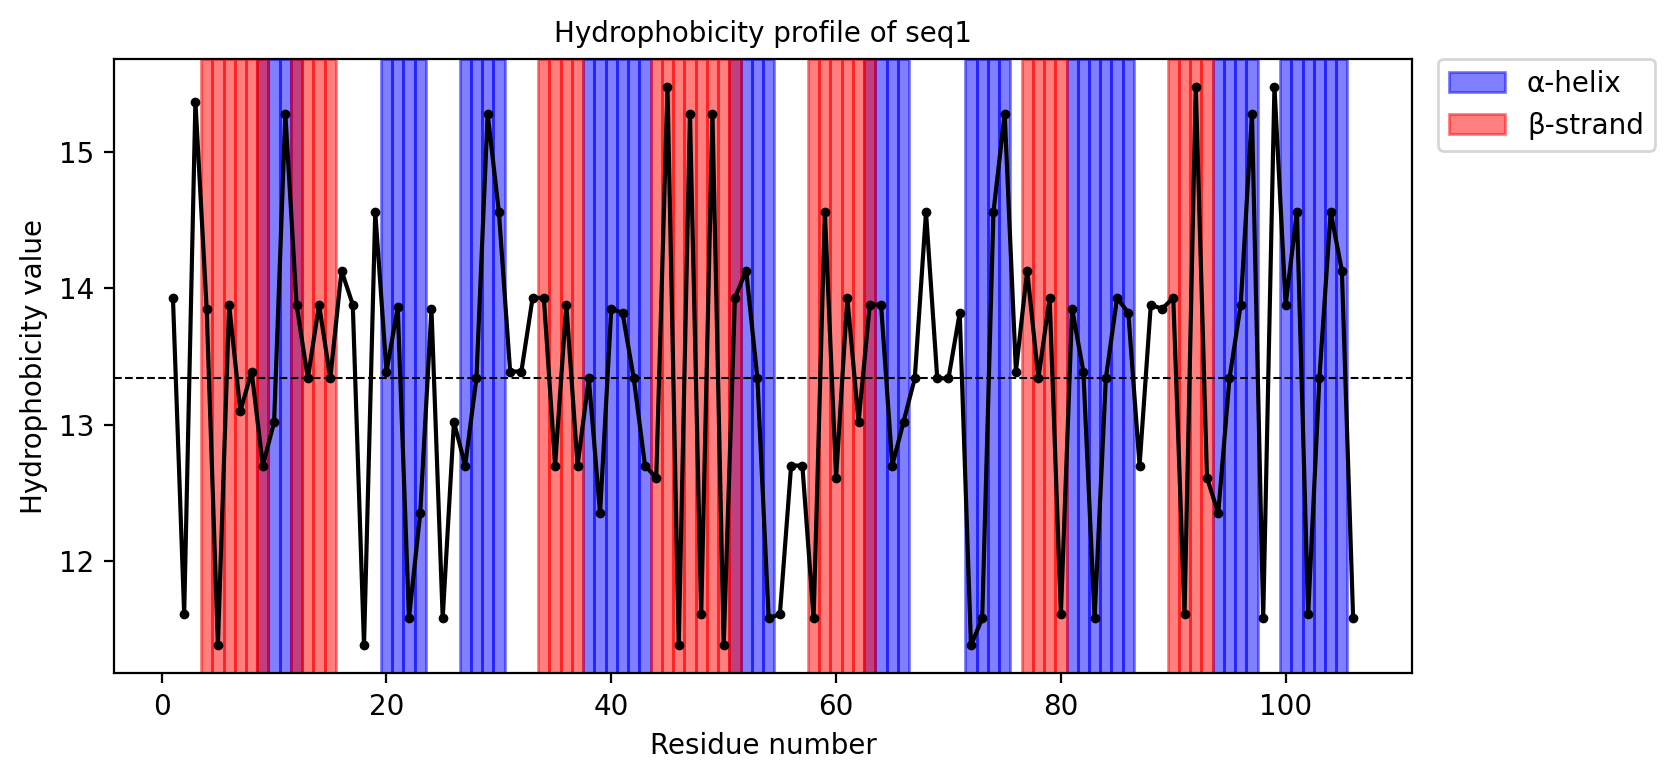

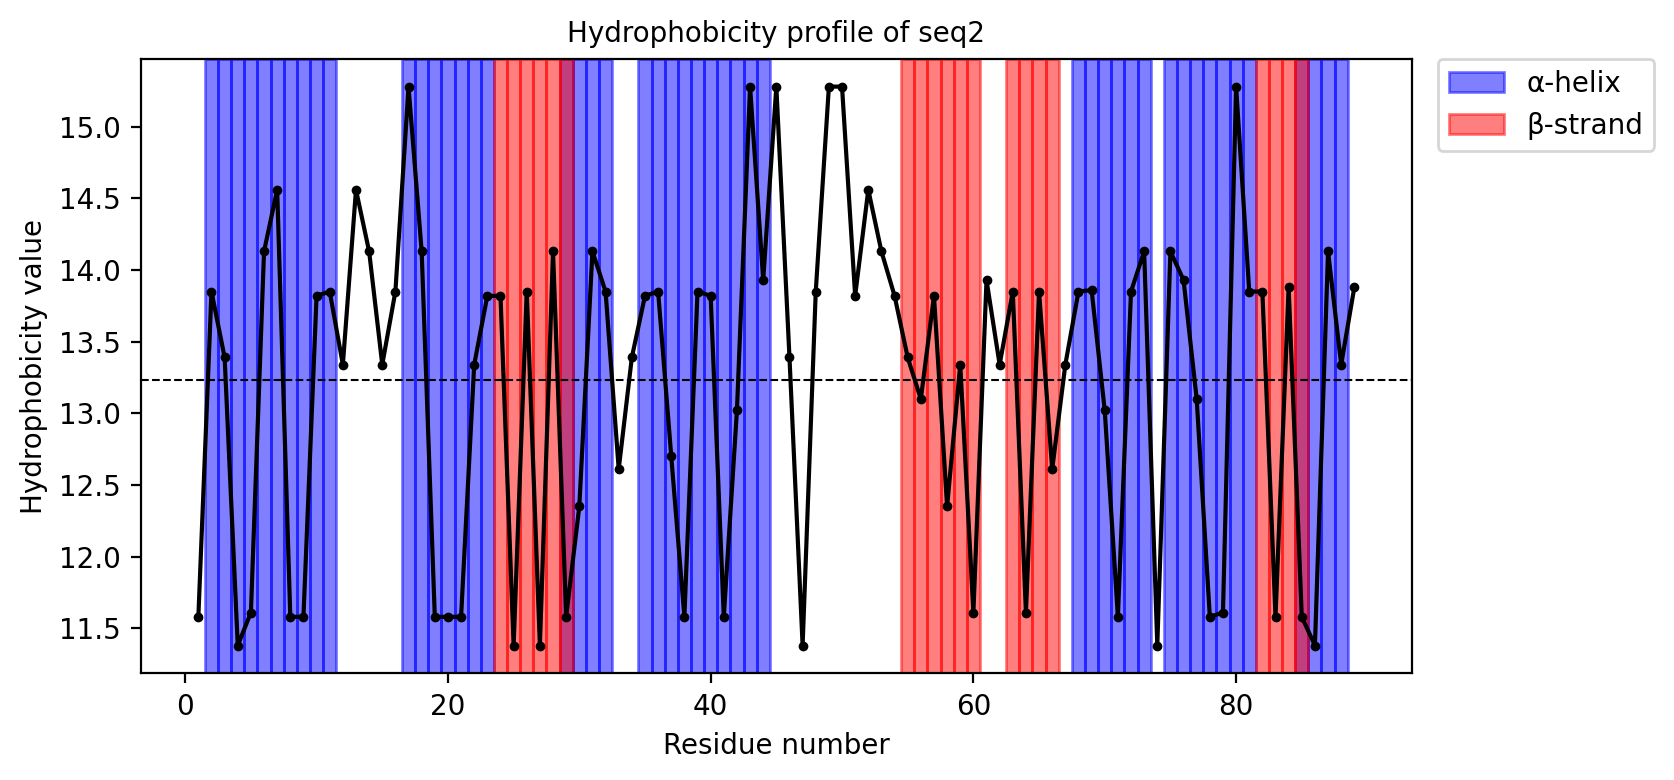

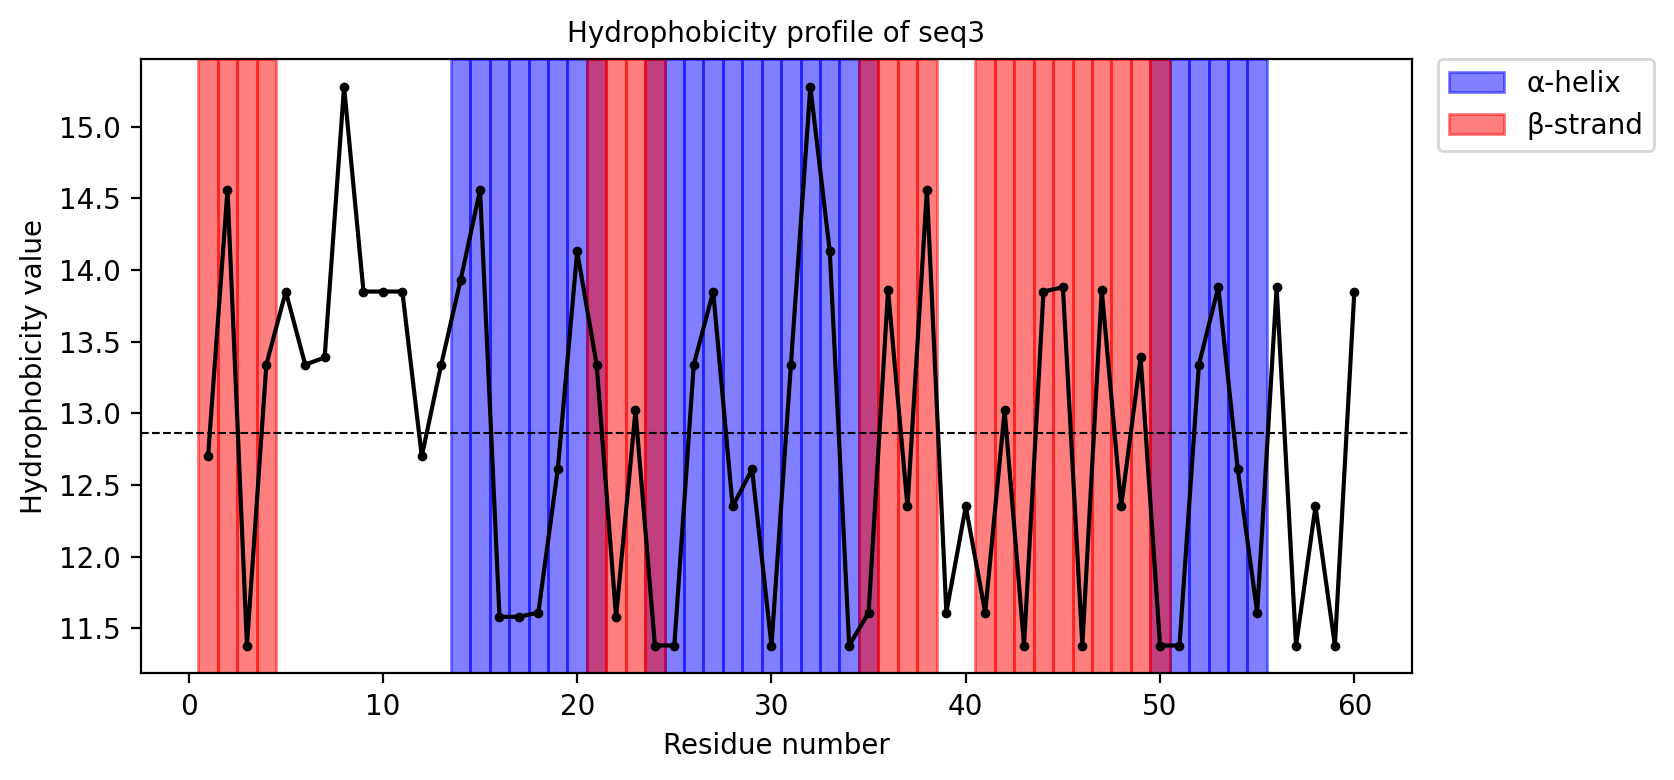

In [6]:
for sequence_id in Sequences.keys():
  sequence = Sequences[sequence_id]
  sec_str_identification(sequence, sequence_id)

In [7]:
# Question 2

def helix_amphipaticity_scoring(frames, seq):
  output = {}
  for frame in frames:
    subseq = (seq[frame[0]:frame[1]+1])

    a1 = (hydrophobicity[subseq[0]]+hydrophobicity[subseq[4]])/2
    a2 = (hydrophobicity[subseq[1]]+hydrophobicity[subseq[5]])/2
    a3 = (hydrophobicity[subseq[2]]+hydrophobicity[subseq[6]])/2
    a4 = (hydrophobicity[subseq[3]]+hydrophobicity[subseq[7]])/2

    A1 = round(abs((a1 + a2) - (a3 + a4)),3)
    A2 = round(abs((a1 + a4) - (a2 + a3)),3)

    A_alpha = max(A1, A2)
    output[subseq] = A_alpha

  return(output)

def strand_amphipaticity_scoring(frames, seq):
  output = {}
  for frame in frames:
    subseq = (seq[frame[0]:frame[1]+1])

    b1 = (hydrophobicity[subseq[0]]+hydrophobicity[subseq[2]]+hydrophobicity[subseq[4]])/3
    b2 = (hydrophobicity[subseq[1]]+hydrophobicity[subseq[3]]+hydrophobicity[subseq[5]])/3

    B = round(abs(b1-b2),3)
    output[subseq] = B

  return(output)

In [8]:
# Getting the frames for amphipaticity score calculations
def amphipathicity(seq_id, seq):
  seq_scores = []

  for AA in seq:
    seq_scores.append(hydrophobicity[AA])
  seq_scores = np.array(seq_scores)
  mean_score = np.mean(seq_scores)
  characterization = np.where(seq_scores > mean_score, 1, -1)

  helix_chains, strand_chains = [], []

  # Identifying α-helices of length 8
  n = 0
  while n < (len(characterization)-7):
    if ((characterization[n] == characterization[n+1]) and (characterization[n] == characterization[n+4]) and (characterization[n] == characterization[n+5]) and
    (characterization[n+2] == characterization[n+3]) and (characterization[n+2] == characterization[n+6]) and (characterization[n+2] == characterization[n+7]) and
    (characterization[n] * characterization[n+2] < 0)):
      helix_chains.append((n,n+7))
    n += 1

  # Identifying β-strands of length 6
  n = 0
  while n < (len(characterization)-5):
    if ((characterization[n] == characterization[n+2]) and (characterization[n] == characterization[n+4]) and
        (characterization[n+1] == characterization[n+3]) and (characterization[n+1] == characterization[n+5]) and
        (characterization[n] * characterization[n+1] < 0)):
      strand_chains.append((n,n+5))
    n += 1
  #-----------------------------------------------------------------------------
  # For α-helices
  if helix_chains == []:
    print(f"No α-helix of 8 or more residues are present in {seq_id}")
  else:
    Helix_Frames = []
    for block in helix_chains:
      lower, upper = block
      n = lower
      while n <= upper-7:
        Helix_Frames.append((n,n+7))
        n+=2

    #print(Helix_Frames)
    helix_amphipathicity_score = helix_amphipaticity_scoring(Helix_Frames, seq)
    for subseq in helix_amphipathicity_score.keys():
      print(f"The α-helix segment {subseq} has an amphipaticity index of: {helix_amphipathicity_score[subseq]}")

  # For β-strands
  if strand_chains == []:
    print(f"No β-strand of 6 or more residues are present in {seq_id}")
  else:
    Strand_Frames = []
    for block in strand_chains:
      lower, upper = block
      n = lower
      while n <= upper-5:
        Strand_Frames.append((n,n+5))
        n+=1

    #print(Strand_Frames)
    strand_amphipathicity_score = strand_amphipaticity_scoring(Strand_Frames, seq)
    for subseq in strand_amphipathicity_score.keys():
      print(f"The β-strands segment {subseq} has an amphipaticity index of: {strand_amphipathicity_score[subseq]}")

  print("="*100)

In [9]:
for seq_id in Sequences.keys():
  print(seq_id)
  amphipathicity(seq_id, Sequences[seq_id])

seq1
No α-helix of 8 or more residues are present in seq1
The β-strands segment AEYRST has an amphipaticity index of: 1.313
The β-strands segment QWEIDI has an amphipaticity index of: 3.48
The β-strands segment WEIDIE has an amphipaticity index of: 3.89
The β-strands segment EIDIEF has an amphipaticity index of: 3.373
The β-strands segment KVQFNY has an amphipaticity index of: 1.72
seq2
The α-helix segment ASEDLVKK has an amphipaticity index of: 4.89
The α-helix segment EDLVKKHA has an amphipaticity index of: 5.105
The α-helix segment HATKAHKN has an amphipaticity index of: 3.23
The α-helix segment TKAHKNIF has an amphipaticity index of: 4.0
The β-strands segment HEAELK has an amphipaticity index of: 2.487
The β-strands segment SRHPGD has an amphipaticity index of: 1.163
The β-strands segment RHPGDF has an amphipaticity index of: 1.343
seq3
No α-helix of 8 or more residues are present in seq3
The β-strands segment YEMPSE has an amphipaticity index of: 2.007


In [10]:
# Question 3
# Reading the file to obtain the sequences!

Sequences = {}

for record in SeqIO.parse("/content/drive/MyDrive/BT3040-Assignments/Lab Assignment - 8/Q2.fasta", "fasta"):
  Sequences[record.id] =  str(record.seq)

In [11]:
def transmembrane_domains(seq, win_len):
  seq_scores = []

  for AA in seq:
    seq_scores.append(hydrophobicity[AA])
  seq_scores = np.array(seq_scores)

  half_win = win_len//2
  profile = []

  for n in range(len(seq_scores)):
      start = max(0, n - half_win)
      end = min(len(seq_scores), n + half_win + 1)
      window = seq_scores[start:end]
      profile.append(np.mean(window))

  profile = np.array(profile)
  threshold = np.mean(profile)
  characterization = np.where(profile > threshold, 1, -1)
  transmembrane_regions = set()

  for n in range(len(characterization) - 10 + 1):
    if np.all(characterization[n:n+10] == 1):
        transmembrane_regions.update(range(n, n+10))

  # For the plot
  positions = np.arange(1, len(profile) + 1)
  fig, ax = plt.subplots(figsize=(10, 4), dpi=200)

  ax.plot(positions, profile, c="black", marker="o", markersize=1.5, label="Hydrophobicity")
  ax.axhline(threshold, c="black", ls="--", lw= 1, label="Mean")

  # Highlight TM regions
  for pos in set(transmembrane_regions):
      ax.axvspan(pos + 0.5, pos + 1.5, alpha=0.5, color="gold")

  # Legend
  tm_patch = mpatches.Patch(color='gold', alpha=0.5, label='Transmembrane')

  # Labels and title
  ax.set_xlabel("Residue position", fontsize=10)
  ax.set_ylabel("Hydrophobicity", fontsize=10)
  ax.set_title("Hydrophobicity Profile", fontsize=10)

  # Legend positioning
  ax.legend(handles=[tm_patch],
            loc='upper left',
            bbox_to_anchor=(1.02, 1),
            borderaxespad=0.)

  plt.tight_layout(rect=[0, 0, 0.85, 1])
  plt.show()
  plt.close(fig)
  print("\n")

1PRC:L|PDBID|CHAIN|SEQUENCE
ALLSFERKYRVRGGTLIGGDLFDFWVGPYFVGFFGVSAIFFIFLGVSLIGYAASQGPTWDPFAISINPPDLKYGLGAAPLLEGGFWQAITVCALGAFISWMLREVEISRKLGIGWHVPLAFCVPIFMFCVLQVFRPLLLGSWGHAFPYGILSHLDWVNNFGYQYLNWHYNPGHMSSVSFLFVNAMALGLHGGLILSVANPGDGDKVKTAEHENQYFRDVVGYSIGALSIHRLGLFLASNIFLTGAFGTIASGPFWTRGWPEWWGWWLDIPFWS


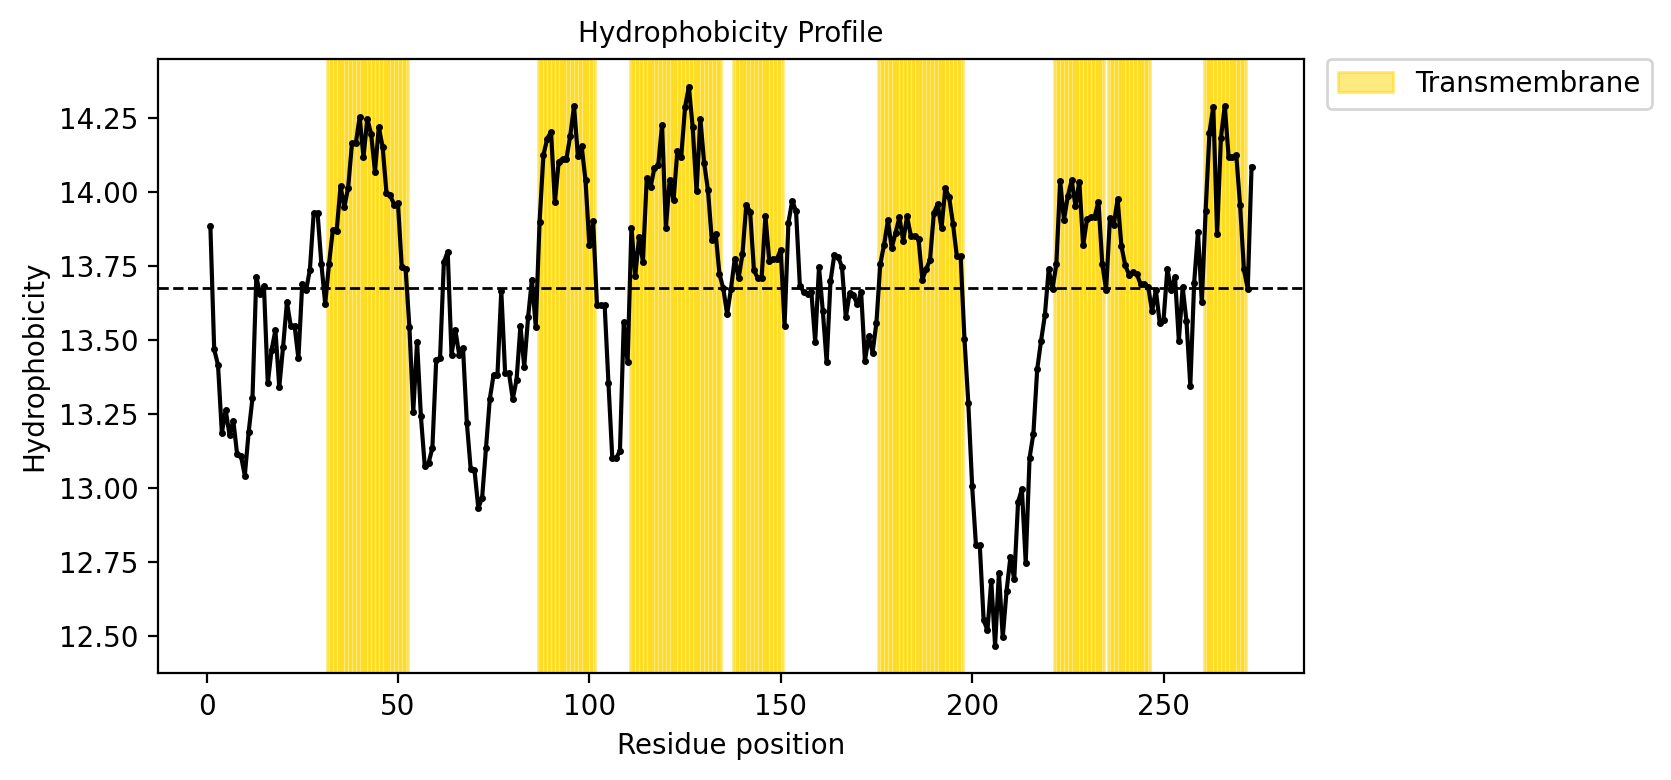

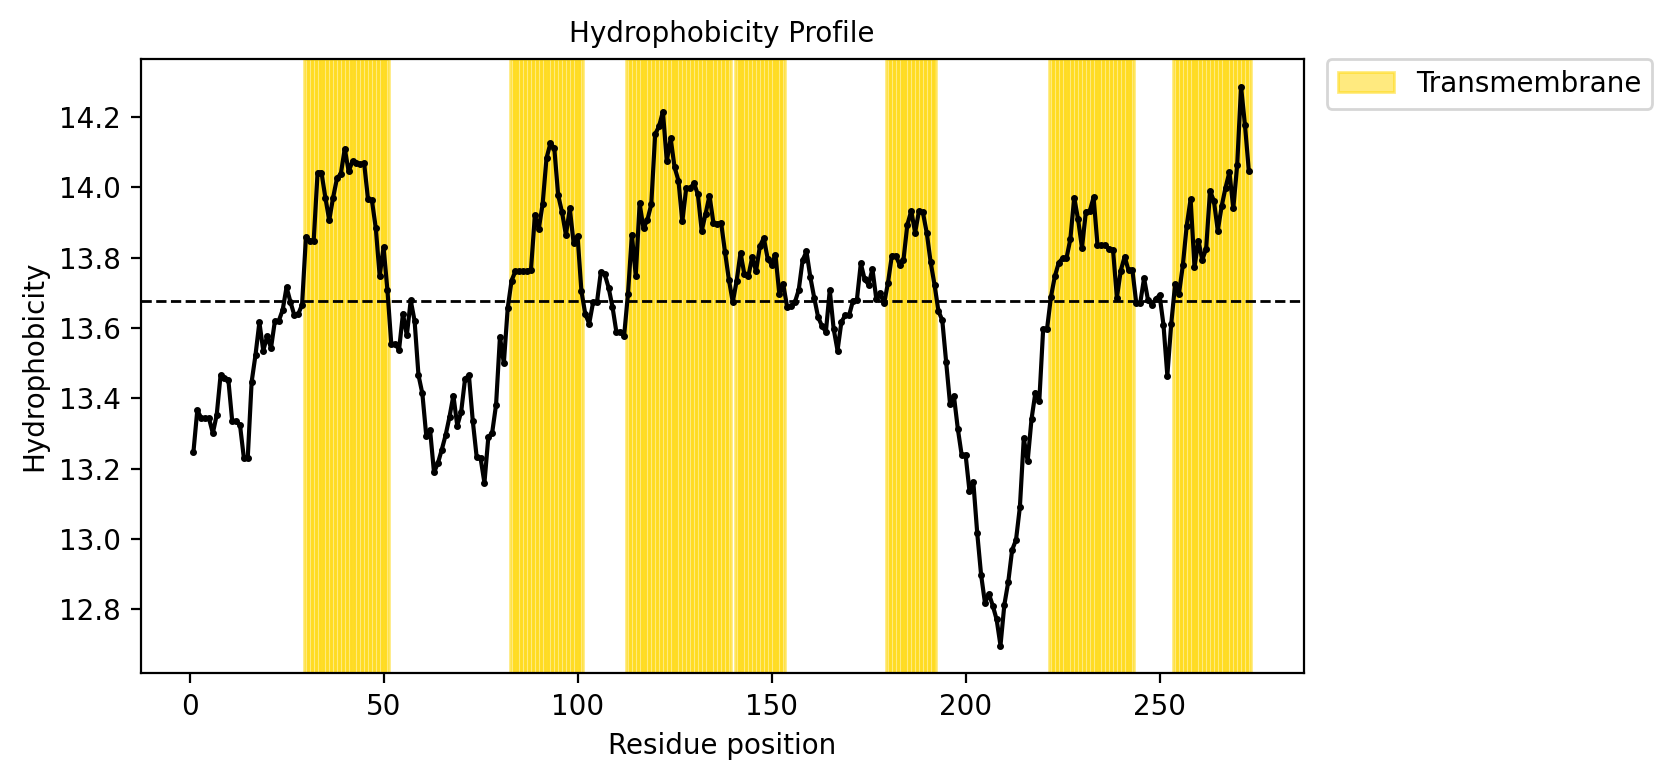

In [12]:
for seq_id in Sequences.keys():
  print(seq_id)
  print(Sequences[seq_id])
  transmembrane_domains(Sequences[seq_id], 9)
  transmembrane_domains(Sequences[seq_id], 19)

In [13]:
# Question 5
# Reading the file to obtain the sequences!

Sequences = {}

for record in SeqIO.parse("/content/drive/MyDrive/BT3040-Assignments/Lab Assignment - 8/Q4.fasta", "fasta"):
  Sequences[record.description] =  str(record.seq)

In [14]:
pattern1 = re.compile(r'[SV]T[VT][DERK]{2}[^IL]')
pattern2 = re.compile(r'[FILV]Q.{3}[^RK]G.{3}[RK].{2}[FILVWY]')

for header in Sequences.keys():
  seq = Sequences[header]
  matches_1 = list(re.finditer(pattern1, seq))
  matches_2 = list(re.finditer(pattern2, seq))

  if matches_1 or matches_2:
    print(header)
    for m in matches_1:
      print(f"Pattern 1 | Position: {m.start()+1} | {m.group()}")
    for m in matches_2:
      print(f"Pattern 2 | Position: {m.start()+1} | {m.group()}")
    print("="*50)

4A0C_2|Chains C,E|CULLIN-4B|HOMO SAPIENS (9606)
Pattern 1 | Position: 665 | STTERV
4A0K_1|Chain A|CULLIN-4A|HOMO SAPIENS (9606)
Pattern 1 | Position: 666 | STTERV
4FXG_2|Chains B,E|Complement C4-A alpha chain|Homo sapiens (9606)
Pattern 2 | Position: 252 | LQIEKEGAIHREEL
4FXK_2|Chain B|Complement C4-A Alpha chain|Homo sapiens (9606)
Pattern 2 | Position: 252 | LQIEKEGAIHREEL
4XAM_2|Chains C,E|Complement C4-A|Homo sapiens (9606)
Pattern 2 | Position: 175 | LQIEKEGAIHREEL
5F0J_3|Chain C|Sorting nexin-3|Homo sapiens (9606)
Pattern 1 | Position: 70 | STVRRR
5F0L_3|Chain C|Sorting nexin-3|Homo sapiens (9606)
Pattern 1 | Position: 70 | STVRRR
5F0M_3|Chain C|Sorting nexin-3|Homo sapiens (9606)
Pattern 1 | Position: 70 | STVRRR
5F0P_3|Chain C|Sorting nexin-3|Homo sapiens (9606)
Pattern 1 | Position: 70 | STVRRR
5JPM_2|Chains B,E|Complement C4-A|Homo sapiens (9606)
Pattern 2 | Position: 252 | LQIEKEGAIHREEL
5JPN_2|Chain B|Complement C4-A|Homo sapiens (9606)
Pattern 2 | Position: 252 | LQIEKEGAI